# 1 · Representations of the scattering tensor
Companion notebook to *Fast reconstruction of tensor tomographic X-ray scattering data for real-time applications*
(Antunes, Pelt & Batenburg, Optics Express, [doi:10.1364/OE.597352](https://doi.org/10.1364/OE.597352)).

We load the simulated 'M' phantom (spherical harmonic coefficients) and convert it to the directional and rank-2
tensor representations of Section 4.1 / Fig. 3. The results are cached for notebooks 02 and 03.

In [1]:
# Colab only: fetch the repository and install mumott (skipped everywhere else)
import os, sys
if 'google.colab' in sys.modules and not os.getcwd().endswith('notebooks'):
    !git clone -q https://github.com/mesqant/algebraic-filters-tt
    %pip install -q mumott==2.1 "scipy<1.17" colorcet
    %cd algebraic-filters-tt/notebooks

In [2]:
# Imports (mumott's INFO logging is silenced)
import logging
import urllib.request
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import h5py
import colorcet  # registers the 'cet_*' colormaps
from tqdm.auto import tqdm
logging.getLogger('mumott').setLevel(logging.WARNING)
from mumott import SphericalHarmonicMapper

In [3]:
# Download the simulated 'M' phantom (Nielsen et al., doi:10.5281/zenodo.7673985) unless it is already cached
data_dir = Path('../data')
data_dir.mkdir(exist_ok=True)
phantom_path = data_dir / 'M_sim_1.0e+01.h5'
if not phantom_path.exists():
    urllib.request.urlretrieve('https://zenodo.org/records/7673985/files/M_sim_1.0e+01.h5', phantom_path)
print(f'{phantom_path}: {phantom_path.stat().st_size / 1e6:.0f} MB')

../data/M_sim_1.0e+01.h5: 189 MB


## Spherical harmonic representation

In [4]:
# Volume size: the 50³ phantom plus zero-padding, with an odd side length so there is a unique central voxel
max_ell = 6                                              # SH expansion cap (even orders up to ℓ = 6)
n_coefficients = (max_ell + 1) * (max_ell + 2) // 2      # 28 coefficients
pad_extra = 6                                            # extra zero-padding around the volume
volume_shape = (51 + pad_extra,) * 3
volume_shape

(57, 57, 57)

In [5]:
# Load the SH coefficients and the mask of the 'M' volume
with h5py.File(phantom_path, 'r') as file:
    M_spherical = file['model/coefficients'][..., :n_coefficients].astype(np.float32)
    M_volume_mask = file['model/main_volume'][:].astype(bool)
M_spherical.shape, M_volume_mask.shape

((50, 50, 50, 28), (50, 50, 50))

In [6]:
# Zero-pad the volume and mask to volume_shape (one extra layer before, pad_extra/2 on both sides)
pad_width = [(1 + pad_extra // 2, pad_extra // 2)] * 3
M_spherical = np.pad(M_spherical, pad_width + [(0, 0)])
M_volume_mask = np.pad(M_volume_mask, pad_width)
M_spherical.shape, M_volume_mask.shape

((57, 57, 57, 28), (57, 57, 57))

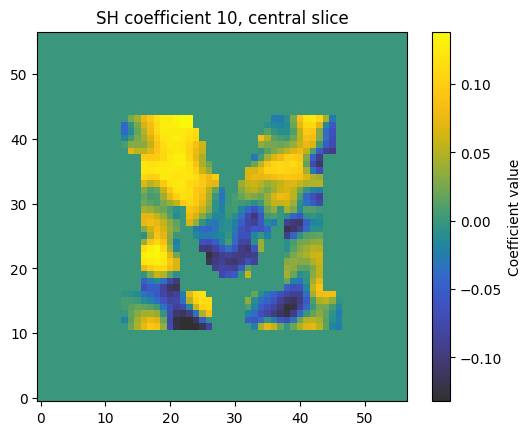

In [7]:
# Show the central slice of one SH coefficient
slice_idx = volume_shape[1] // 2
coeff_idx = 10
plt.imshow(M_spherical[:, slice_idx, :, coeff_idx].T, cmap='cet_gouldian', origin='lower')
plt.colorbar(label='Coefficient value')
plt.title(f'SH coefficient {coeff_idx}, central slice');

## Directional representation
Values of the spherical function along 7 fixed directions (GITT-style, Kim et al.), cf. Fig. 3(b).

In [8]:
# The 7 normalised directions: the 3 axes and 4 cube diagonals
directions = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1],
                       [1, 1, 1], [1, -1, -1], [-1, 1, -1], [-1, -1, 1]], dtype=np.float32)
directions /= np.linalg.norm(directions, axis=1, keepdims=True)
directions

array([[ 1.        ,  0.        ,  0.        ],
       [ 0.        ,  1.        ,  0.        ],
       [ 0.        ,  0.        ,  1.        ],
       [ 0.57735026,  0.57735026,  0.57735026],
       [ 0.57735026, -0.57735026, -0.57735026],
       [-0.57735026,  0.57735026, -0.57735026],
       [-0.57735026, -0.57735026,  0.57735026]], dtype=float32)

In [9]:
# Coarse SH evaluation grid and, per direction, the index of the nearest grid point in (φ, θ)
# Note: the directional values are taken at the nearest point of this grid rather than exactly at the 7 directions,
#       as was done for the results in the paper.
coarse_mapper = SphericalHarmonicMapper(ell_max=max_ell, azimuthal_resolution=8, polar_resolution=47)
phi_targets = np.arctan2(directions[:, 1], directions[:, 0])
theta_targets = np.arccos(directions[:, 2])
directional_indices = [np.argmin((coarse_mapper.phi.ravel() - phi) ** 2 + (coarse_mapper.theta.ravel() - theta) ** 2)
                       for phi, theta in zip(phi_targets, theta_targets)]
directional_indices

[188, 190, 0, 117, 259, 263, 113]

In [10]:
# Voxels with any non-zero coefficient (all other voxels stay zero in every representation)
signal_voxels = np.argwhere(np.any(M_spherical != 0, axis=-1))
f'{len(signal_voxels)} of {np.prod(volume_shape)} voxels carry signal'

'60392 of 185193 voxels carry signal'

In [11]:
# Evaluate each voxel's spherical function and keep the 7 directional values
M_directional = np.zeros(volume_shape + (len(directions),), dtype=np.float32)
for i, j, k in tqdm(signal_voxels, desc='SH → directional'):
    M_directional[i, j, k] = coarse_mapper.get_amplitudes(M_spherical[i, j, k]).ravel()[directional_indices]

SH → directional:   0%|          | 0/60392 [00:00<?, ?it/s]

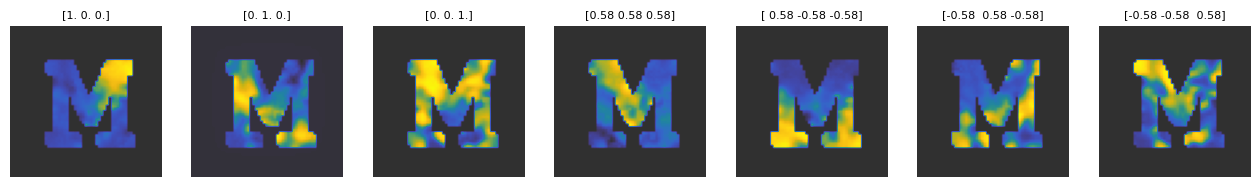

In [12]:
# Show the central slice for each direction
fig, axes = plt.subplots(1, len(directions), figsize=(16, 2.6))
for d, ax in enumerate(axes):
    ax.imshow(M_directional[:, slice_idx, :, d].T, cmap='cet_gouldian', origin='lower')
    ax.set_title(str(np.round(directions[d], 2)), fontsize=8)
    ax.axis('off')

## Rank-2 tensor representation
Second angular moment $T = \int f(\hat n)\, \hat n \otimes \hat n \, d\Omega$ (Eq. 14): a symmetric 3×3 tensor with
6 unique entries per voxel (Lautizi et al.), cf. Fig. 3(c).

In [13]:
# Fine SH evaluation grid over the full sphere, its unit vectors and the 6 unique outer products n_a n_b
fine_mapper = SphericalHarmonicMapper(ell_max=max_ell, azimuthal_resolution=128, polar_resolution=64)
theta_flat, phi_flat = fine_mapper.theta.ravel(), fine_mapper.phi.ravel()
unit_vectors = np.stack([np.sin(theta_flat) * np.cos(phi_flat),
                         np.sin(theta_flat) * np.sin(phi_flat),
                         np.cos(theta_flat)], axis=1)
tensor_components = [(0, 0), (1, 1), (2, 2), (0, 1), (0, 2), (1, 2)]
outer_products = np.stack([unit_vectors[:, a] * unit_vectors[:, b] for a, b in tensor_components], axis=1)
outer_products.shape

(8192, 6)

In [14]:
# Quadrature weights sin(θ)·4π/N
# Note: for this uniform (θ, φ) grid the exact solid-angle element is sin(θ)ΔθΔφ, so these weights differ from Eq. 14
#       by a constant factor (≈ 2/π). This rescales all tensor entries uniformly and does not affect relative errors.
quadrature_weights = np.sin(theta_flat) * 4 * np.pi / theta_flat.size
quadrature_weights.sum(), 4 * np.pi

(7.873368053328935, 12.566370614359172)

In [15]:
# Integrate each voxel's spherical function, after an isotropic shift that makes it non-negative (→ PSD tensor)
# Note: the shift is chosen per voxel (and only applied where the function dips below zero), as for the paper's
#       results; the paper text describes it as a global isotropic shift.
M_tensor = np.zeros(volume_shape + (len(tensor_components),), dtype=np.float32)
for i, j, k in tqdm(signal_voxels, desc='SH → tensor'):
    values = fine_mapper.get_amplitudes(M_spherical[i, j, k]).ravel()
    values -= min(values.min(), 0.)  # isotropic shift: adds the same constant in every direction
    M_tensor[i, j, k] = (values * quadrature_weights) @ outer_products

SH → tensor:   0%|          | 0/60392 [00:00<?, ?it/s]

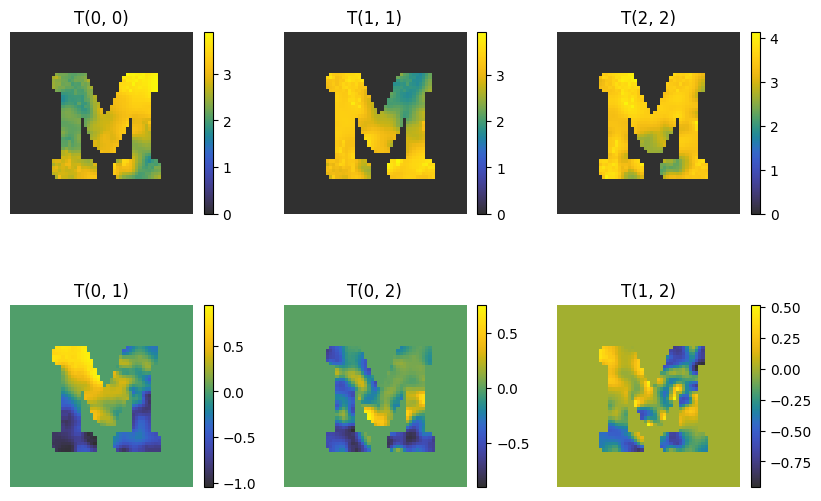

In [16]:
# Show the central slice of the 6 tensor entries (diagonal entries top row, off-diagonal bottom row)
fig, axes = plt.subplots(2, 3, figsize=(10, 6.5))
for c, ax in enumerate(axes.flat):
    im = ax.imshow(M_tensor[:, slice_idx, :, c].T, cmap='cet_gouldian', origin='lower')
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f'T{tensor_components[c]}')
    ax.axis('off')

In [17]:
# Cache the three representations and the mask for notebooks 02 and 03
np.savez(data_dir / 'phantom_representations.npz',
         spherical=M_spherical, directional=M_directional, tensor=M_tensor, mask=M_volume_mask,
         directions=directions, max_ell=max_ell, pad_extra=pad_extra)
sorted((data_dir).iterdir())

[PosixPath('../data/.gitkeep'),
 PosixPath('../data/M_sim_1.0e+01.h5'),
 PosixPath('../data/phantom_representations.npz')]